# InmoStats - EDA: Apartamentos en venta en Colombia

Exploración inicial del dataset consolidado (fincaraiz.com.co, scraping nacional).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from src.pipelines.clean_data import clean, engineer_features, load_raw_data

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

## 1. Carga y limpieza

Usamos el mismo pipeline de `src/pipelines/clean_data.py` (no una copia aparte), así el EDA siempre refleja exactamente la lógica de limpieza real del proyecto.

In [2]:
df = load_raw_data()
df = clean(df)
df = engineer_features(df)

print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
df.head(3)

2026-07-06 13:57:18,649 [INFO] Cargando 22 archivo(s) crudo(s)


C:\Users\ASUS\Documents\C-Proyect\inmostats\src\pipelines\clean_data.py:83: DtypeWarning: Columns (0: locality) have mixed types. Specify dtype option on import or set low_memory=False.
  frames = [pd.read_csv(f, encoding="utf-8-sig") for f in csv_files]


2026-07-06 13:57:21,468 [INFO] Registros tras deduplicar por listing_id: 47301


2026-07-06 13:57:21,567 [INFO] Registros descartados por limpieza: 442 (de 47301)


2026-07-06 13:57:21,685 [INFO] department_final inferido por ciudad para 1157/1158 filas sin departamento real


Filas: 46,859  |  Columnas: 38


,listing_id,title,description,address,detail_url,department_slug,department,city,neighborhood,locality,zone,latitude,longitude,price_cop,admin_fee_cop,bedrooms,bathrooms,area_m2,area_built_m2,stratum,floor,floors_count,antiquity,construction_year,garages,amenities,is_new_project,owner_type,owner_name,image_count,main_image_url,listing_created_at,listing_updated_at,source_page,scraped_at,department_real,price_per_m2,department_final
3,6677425,"OIKOS PALMA REAL, Apartamentos en Venta en Fla...",¡PRECIO FIJO EN PESOS!\nOikos Palma Real es un...,"OIKOS Palma Real - Apartamentos Flandes, 300 m...",https://www.fincaraiz.com.co/proyectos-viviend...,tolima,Tolima,Flandes,Flandes,sin especificar,sin especificar,4.262546,-74.832430,224084850,0,3,2,57.15,57.15,3.0,NaN,0,NaN,NaN,0,Zonas Verdes\r; Zona Residencial\r; Zona Infan...,True,desarrollador,GRUPO EMPRESARIAL OIKOS,14,https://cdn2.infocasas.com.uy/repo/img/6a32c0f...,2021-09-13,2026-06-17,1,2026-07-03 17:36:48.148659+00:00,sin especificar,3920995.0,Tolima
5,6915016,"VENTUM, Apartamento en Venta en Hacienda Santa...",[PLACEHOLDER],[PLACEHOLDER],https://www.fincaraiz.com.co/ventum-apartament...,tolima,Tolima,Ibagué,Hacienda Santa Cruz,sin especificar,Bolivar,4.426514,-75.164940,175500000,0,2,1,56.00,0.00,3.0,0.0,0,0.0,NaN,0,Cómodas vias de acceso; Gimnasio; Salón Comuna...,True,desarrollador,AMARILO,17,https://s3.amazonaws.com/imagenesprof.fincarai...,2021-12-15,2025-02-17,1,2026-07-03 17:36:48.148701+00:00,sin especificar,3133929.0,Tolima
9,193715502,"Apartamento en Venta en Zona industrial, Ibagué",¡Deja de pagar arriendo y estrena en Ibagué! \...,"CRGP+PGV Ibagué, Tolima, Colombia",https://www.fincaraiz.com.co/apartamento-en-ve...,tolima,Tolima,Ibagué,Zona industrial,sin especificar,Bolivar,4.426863,-75.163703,207600000,0,3,1,56.00,56.00,3.0,0.0,0,1.0,NaN,1,Colegios / Universidades; Gimnasio; Piscina; P...,False,inmobiliaria,AMARILO,18,https://cdn2.infocasas.com.uy/repo/img/69fb7f2...,2026-05-06,2026-06-09,1,2026-07-03 17:36:48.148782+00:00,sin especificar,3707143.0,Tolima


## 2. Panorama general: tipos, nulos, duplicados

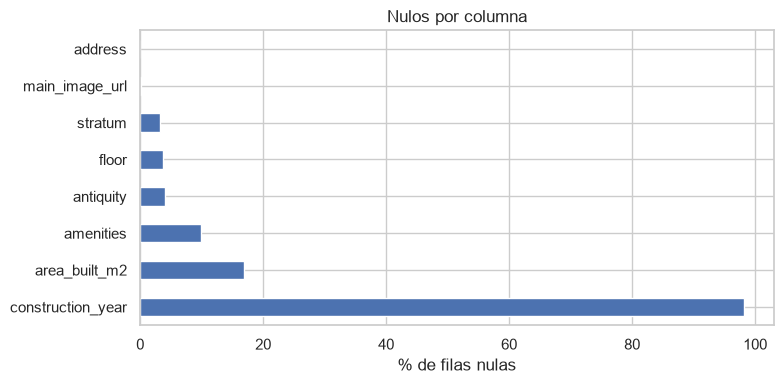

Duplicados por listing_id (deberia ser 0): 0


In [3]:
nulls = df.isna().mean().sort_values(ascending=False) * 100
nulls = nulls[nulls > 0]

fig, ax = plt.subplots(figsize=(8, max(4, len(nulls) * 0.3)))
nulls.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("% de filas nulas")
ax.set_title("Nulos por columna")
plt.tight_layout()
plt.show()

print(f"Duplicados por listing_id (deberia ser 0): {df['listing_id'].duplicated().sum()}")

## 3. Distribución de precio y precio/m²

El precio de vivienda suele venir sesgado a la derecha (pocas propiedades muy caras) — miramos escala normal y log.

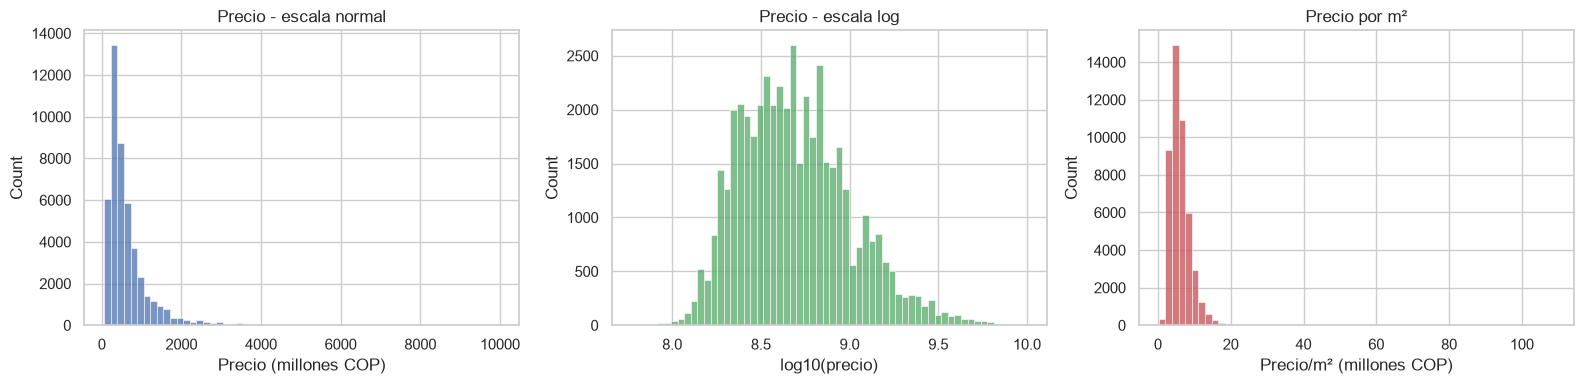

,price_cop,price_per_m2,area_m2
count,"46,859","46,859","46,859"
mean,"658,495,605","6,084,450",104
std,"664,555,309","2,887,080",72
min,"59,000,000","248,976",15
25%,"285,000,000","4,107,143",60
50%,"460,000,000","5,512,821",80
75%,"760,000,000","7,384,615",121
max,"9,990,000,000","108,888,889","1,000"


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(df["price_cop"] / 1e6, bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_xlabel("Precio (millones COP)")
axes[0].set_title("Precio - escala normal")

sns.histplot(np.log10(df["price_cop"]), bins=60, ax=axes[1], color="#55A868")
axes[1].set_xlabel("log10(precio)")
axes[1].set_title("Precio - escala log")

sns.histplot(df["price_per_m2"] / 1e6, bins=60, ax=axes[2], color="#C44E52")
axes[2].set_xlabel("Precio/m² (millones COP)")
axes[2].set_title("Precio por m²")

plt.tight_layout()
plt.show()

df[["price_cop", "price_per_m2", "area_m2"]].describe().apply(lambda s: s.map(lambda v: f"{v:,.0f}"))

## 4. Precio por departamento

`department_final` (departamento real del anuncio, no la zona de búsqueda) — ver README para la explicación de por qué esto importa para "Resto de Colombia".

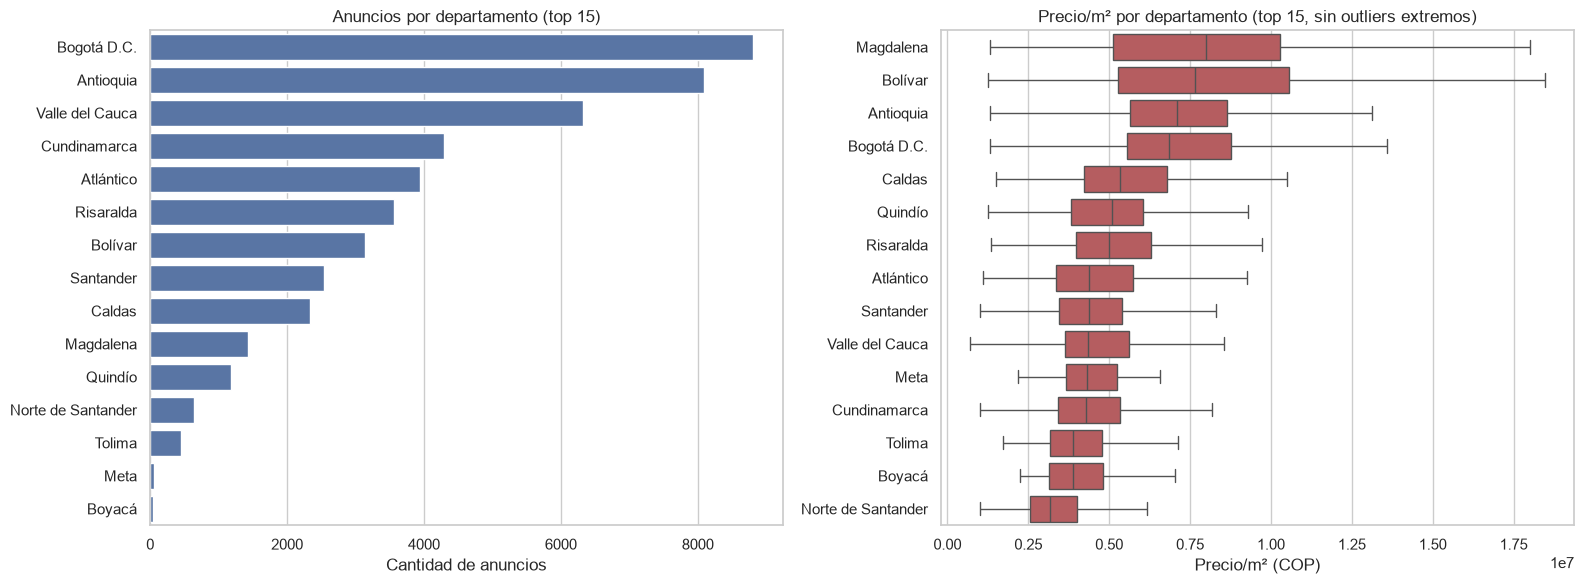

In [5]:
top_departments = df["department_final"].value_counts().head(15).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order_count = df["department_final"].value_counts().loc[top_departments].index
sns.countplot(data=df[df["department_final"].isin(top_departments)], y="department_final",
              order=order_count, ax=axes[0], color="#4C72B0")
axes[0].set_title("Anuncios por departamento (top 15)")
axes[0].set_xlabel("Cantidad de anuncios")
axes[0].set_ylabel("")

order_price = (
    df[df["department_final"].isin(top_departments)]
    .groupby("department_final")["price_per_m2"].median()
    .sort_values(ascending=False).index
)
sns.boxplot(data=df[df["department_final"].isin(top_departments)], y="department_final",
            x="price_per_m2", order=order_price, ax=axes[1], showfliers=False, color="#C44E52")
axes[1].set_title("Precio/m² por departamento (top 15, sin outliers extremos)")
axes[1].set_xlabel("Precio/m² (COP)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

## 5. Top ciudades por volumen y precio

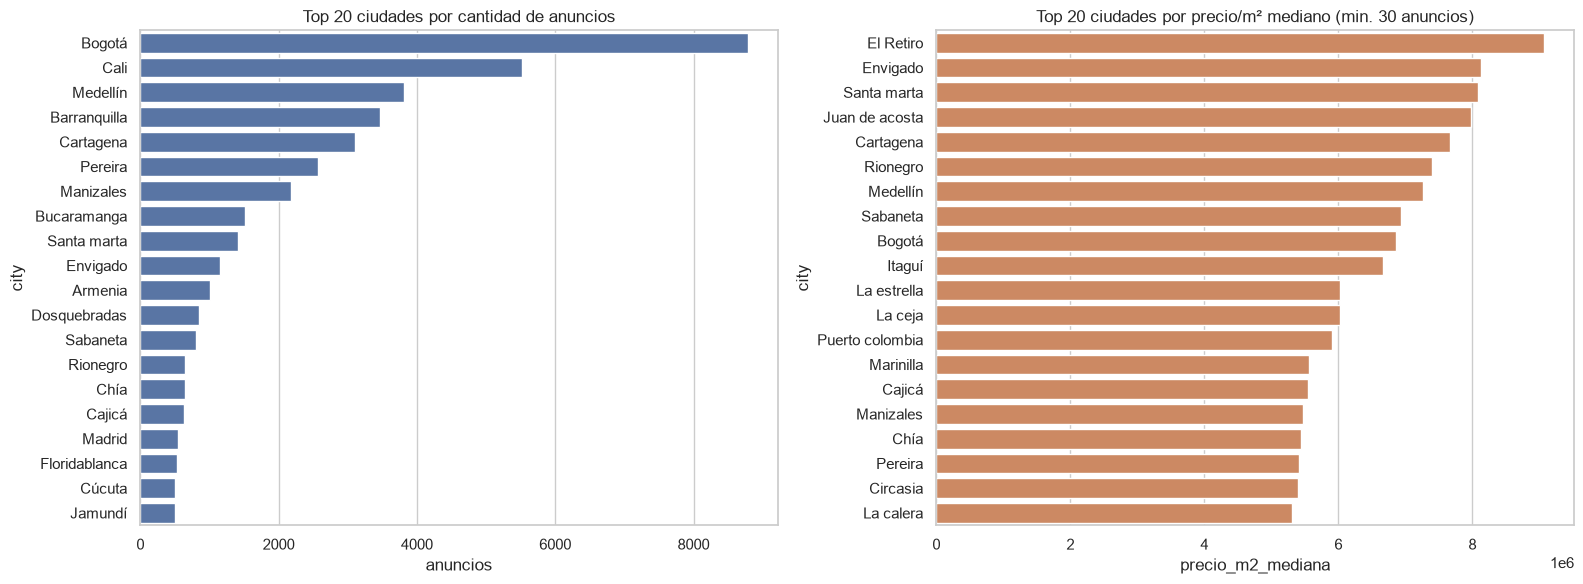

In [6]:
city_stats = (
    df.groupby("city")
    .agg(anuncios=("listing_id", "count"), precio_m2_mediana=("price_per_m2", "median"))
    .query("anuncios >= 30")
    .sort_values("anuncios", ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top20_vol = city_stats.head(20)
sns.barplot(x=top20_vol["anuncios"], y=top20_vol.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Top 20 ciudades por cantidad de anuncios")

top20_price = city_stats.sort_values("precio_m2_mediana", ascending=False).head(20)
sns.barplot(x=top20_price["precio_m2_mediana"], y=top20_price.index, ax=axes[1], color="#DD8452")
axes[1].set_title("Top 20 ciudades por precio/m² mediano (min. 30 anuncios)")

plt.tight_layout()
plt.show()

## 6. Estrato, habitaciones, baños vs. precio

El estrato socioeconómico es, a priori, una de las variables más predictivas en el mercado colombiano.

2026-07-06 13:57:23,181 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-06 13:57:23,193 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-06 13:57:23,252 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-06 13:57:23,269 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-06 13:57:23,322 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-06 13:57:23,335 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


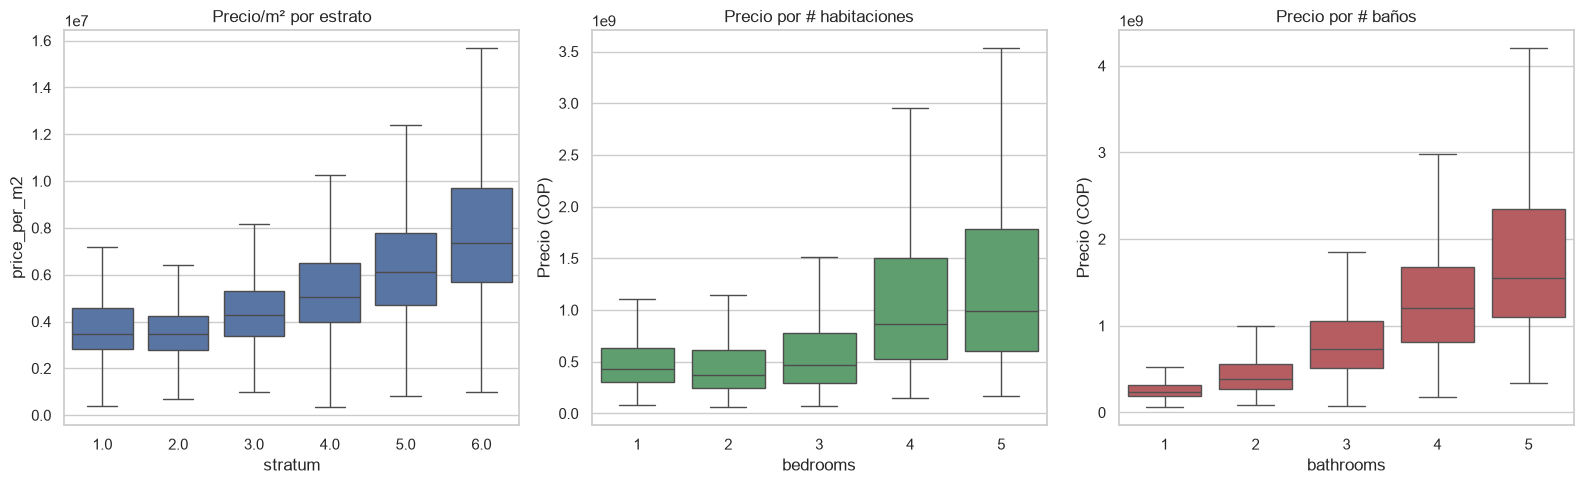

Correlacion (Spearman) con price_cop:


price_cop    1.000000
area_m2      0.794098
stratum      0.751502
garages      0.685096
bathrooms    0.664317
bedrooms     0.240500
antiquity    0.091145
floor        0.009405
Name: price_cop, dtype: float64

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=df.dropna(subset=["stratum"]), x="stratum", y="price_per_m2", ax=axes[0],
            showfliers=False, color="#4C72B0")
axes[0].set_title("Precio/m² por estrato")

sns.boxplot(data=df[df["bedrooms"] <= 5], x="bedrooms", y="price_cop", ax=axes[1],
            showfliers=False, color="#55A868")
axes[1].set_title("Precio por # habitaciones")
axes[1].set_ylabel("Precio (COP)")

sns.boxplot(data=df[df["bathrooms"] <= 5], x="bathrooms", y="price_cop", ax=axes[2],
            showfliers=False, color="#C44E52")
axes[2].set_title("Precio por # baños")
axes[2].set_ylabel("Precio (COP)")

plt.tight_layout()
plt.show()

print("Correlacion (Spearman) con price_cop:")
numeric_cols = ["area_m2", "bedrooms", "bathrooms", "stratum", "floor", "antiquity", "garages"]
df[numeric_cols + ["price_cop"]].corr(method="spearman")["price_cop"].sort_values(ascending=False)

## 7. Proyecto nuevo vs. usado, y tipo de propietario

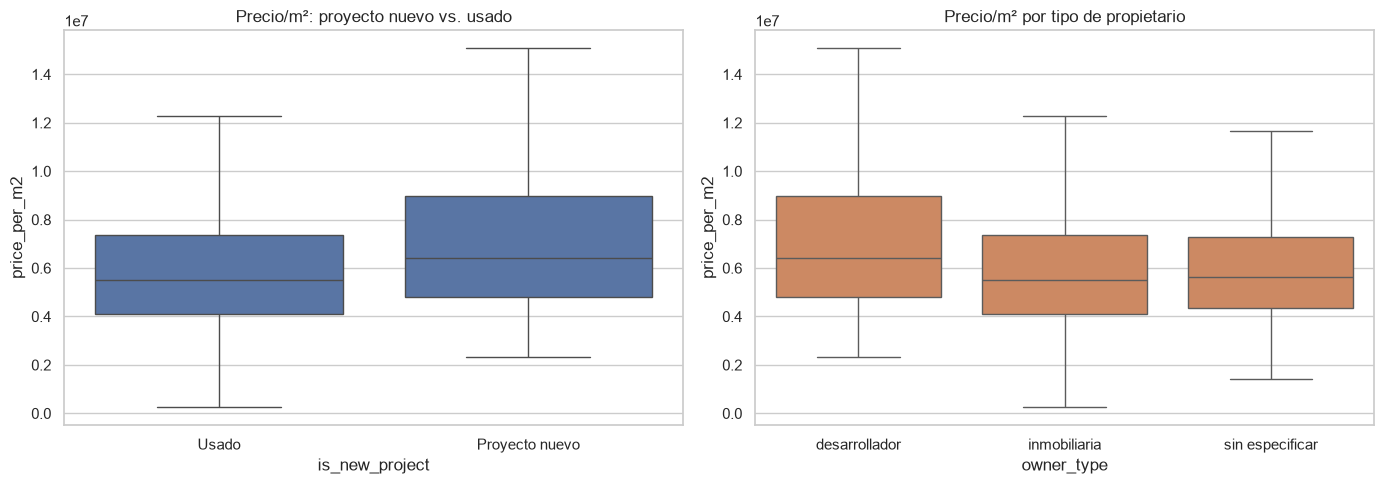

owner_type
inmobiliaria       95.2
sin especificar     3.2
desarrollador       1.5
Name: proportion, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="is_new_project", y="price_per_m2", ax=axes[0], showfliers=False, color="#4C72B0")
axes[0].set_title("Precio/m²: proyecto nuevo vs. usado")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Usado", "Proyecto nuevo"])

owner_top = df["owner_type"].value_counts()
sns.boxplot(data=df[df["owner_type"].isin(owner_top.index)], x="owner_type", y="price_per_m2",
            ax=axes[1], showfliers=False, color="#DD8452")
axes[1].set_title("Precio/m² por tipo de propietario")

plt.tight_layout()
plt.show()

print(df["owner_type"].value_counts(normalize=True).mul(100).round(1))

## 8. Mapa de dispersión (lat/lon coloreado por precio/m²)

Bogotá y las principales ciudades por separado para que se noten los patrones (todo el país junto se ve muy comprimido).

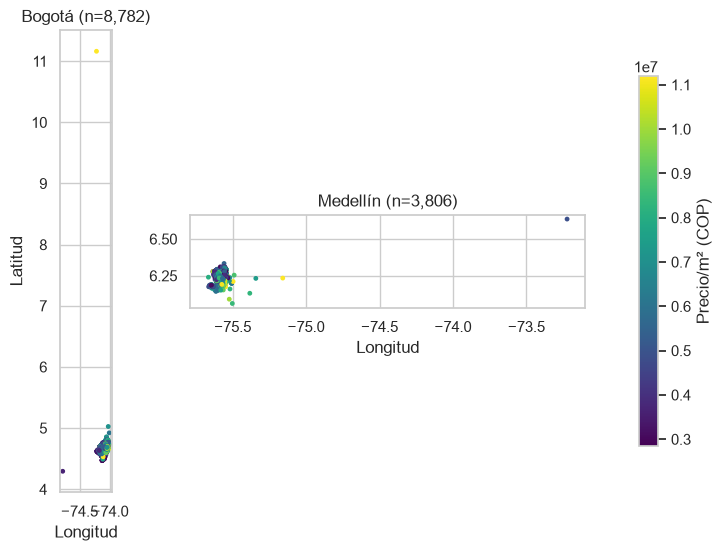

In [9]:
geo = df.dropna(subset=["latitude", "longitude"])
geo = geo[(geo["latitude"].between(-5, 13)) & (geo["longitude"].between(-82, -66))]  # Colombia bbox

cities_to_plot = ["bogotá", "medellín"]
fig, axes = plt.subplots(1, len(cities_to_plot), figsize=(14, 6))

vmin, vmax = geo["price_per_m2"].quantile([0.05, 0.95])

for ax, city in zip(axes, cities_to_plot):
    sub = geo[geo["city"].str.lower() == city]
    sc = ax.scatter(sub["longitude"], sub["latitude"], c=sub["price_per_m2"],
                     cmap="viridis", s=6, vmin=vmin, vmax=vmax)
    ax.set_title(f"{city.title()} (n={len(sub):,})")
    ax.set_xlabel("Longitud")
    ax.set_aspect("equal")

axes[0].set_ylabel("Latitud")
fig.colorbar(sc, ax=axes, label="Precio/m² (COP)", shrink=0.8)
plt.show()

### 8.1 Versión pulida: mapa interactivo con calles reales

El scatter de arriba reveló un dato mal capturado (un anuncio de "Bogotá" con latitud ~11, zona Caribe) que aplastaba la escala — lo filtramos aquí por rango intercuartílico (IQR) de coordenadas por ciudad antes de graficar. La versión interactiva (Plotly + OpenStreetMap, sin necesidad de token) también deja hacer zoom/pan y ver el título y precio de cada anuncio al pasar el mouse.

In [10]:
def filter_coord_outliers(data, k=3):
    """Descarta coordenadas fuera de k * IQR del rango intercuartilico,
    calculado por ciudad (evita que un dato mal capturado, como el de
    latitud ~11 encontrado en Bogota, arruine la escala del mapa)."""
    keep_mask = pd.Series(True, index=data.index)
    for _, sub in data.groupby("city"):
        for col in ("latitude", "longitude"):
            q1, q3 = sub[col].quantile([0.25, 0.75])
            iqr = max(q3 - q1, 1e-4)
            out_of_range = ~sub[col].between(q1 - k * iqr, q3 + k * iqr)
            keep_mask.loc[sub.index[out_of_range]] = False
    return data[keep_mask]

# Filtramos primero a las ciudades que vamos a graficar: aplicar el IQR
# sobre las ~150 ciudades de "geo" haria que ciudades con pocos anuncios
# (muestra chica -> IQR inestable) marcaran de mas como outlier sin
# relacion con el problema real que buscamos corregir.
geo_target = geo[geo["city"].str.lower().isin(cities_to_plot)]
geo_clean = filter_coord_outliers(geo_target)
print(f"Outliers de coordenadas removidos: {len(geo_target) - len(geo_clean)}")

for city in cities_to_plot:
    sub = geo_clean[geo_clean["city"].str.lower() == city]
    fig = px.scatter_map(
        sub, lat="latitude", lon="longitude", color="price_per_m2",
        color_continuous_scale="Viridis", zoom=10.5, height=500,
        map_style="open-street-map",
        hover_name="title",
        hover_data={"price_cop": ":,.0f", "area_m2": True, "latitude": False, "longitude": False},
        range_color=sub["price_per_m2"].quantile([0.05, 0.95]).tolist(),
        title=f"{city.title()} — precio/m² (n={len(sub):,})",
    )
    fig.update_layout(margin={"r": 0, "t": 40, "b": 0, "l": 0})
    fig.show()

Outliers de coordenadas removidos: 11


## 9. Precio vs. área por departamento

¿La relación precio-área es la misma en todo el país, o cada m² adicional vale distinto según la ciudad?

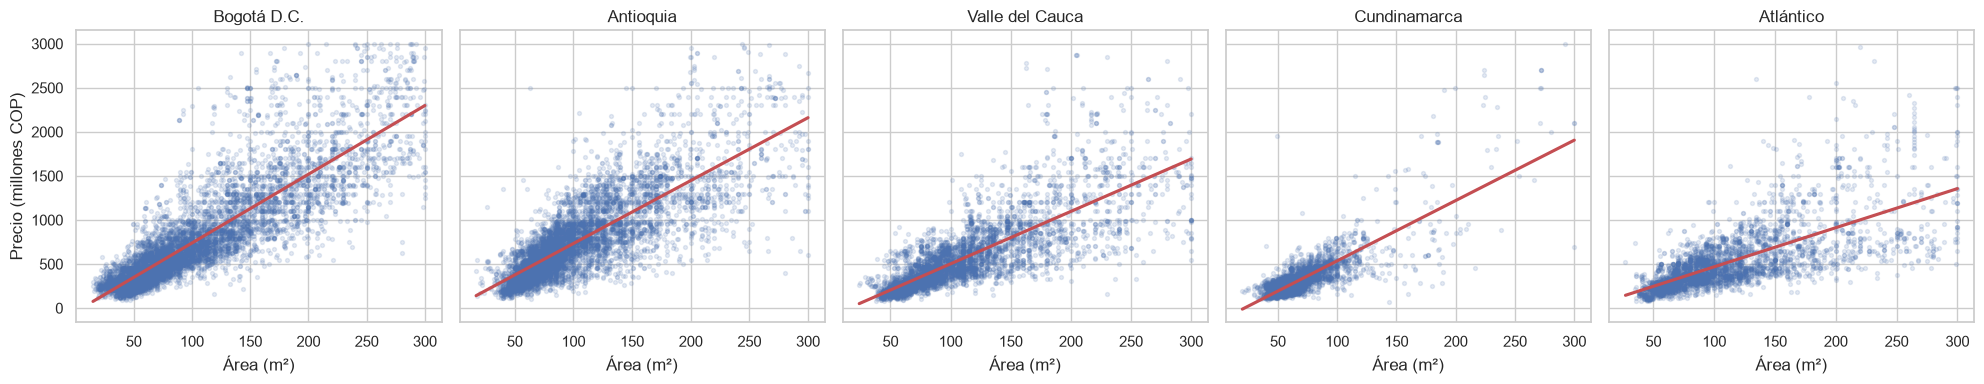

Pendiente aproximada (COP por m² adicional) por departamento:
  Bogotá D.C.          ~7,799,788 COP/m²
  Antioquia            ~7,137,119 COP/m²
  Valle del Cauca      ~5,946,263 COP/m²
  Cundinamarca         ~6,847,695 COP/m²
  Atlántico            ~4,434,170 COP/m²


In [11]:
top5_dept = df["department_final"].value_counts().head(5).index
subset = df[
    df["department_final"].isin(top5_dept) & (df["area_m2"] <= 300) & (df["price_cop"] <= 3e9)
].copy()
subset["price_millones"] = subset["price_cop"] / 1e6

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, dept in zip(axes, top5_dept):
    d = subset[subset["department_final"] == dept]
    sns.regplot(
        data=d, x="area_m2", y="price_millones", ax=ax, ci=None,
        scatter_kws={"alpha": 0.15, "s": 8, "color": "#4C72B0"}, line_kws={"color": "#C44E52"},
    )
    ax.set_title(dept)
    ax.set_xlabel("Área (m²)")
    ax.set_ylabel("")
axes[0].set_ylabel("Precio (millones COP)")
plt.tight_layout()
plt.show()

print("Pendiente aproximada (COP por m² adicional) por departamento:")
for dept in top5_dept:
    d = subset[subset["department_final"] == dept]
    slope = np.polyfit(d["area_m2"], d["price_cop"], 1)[0]
    print(f"  {dept:20} ~{slope:,.0f} COP/m²")

## 10. Precio/m² por departamento × estrato

¿El efecto del estrato es parejo en todo el país, o cambia según la región? Si cambia, es señal de que conviene modelar la interacción, no solo las dos variables por separado.

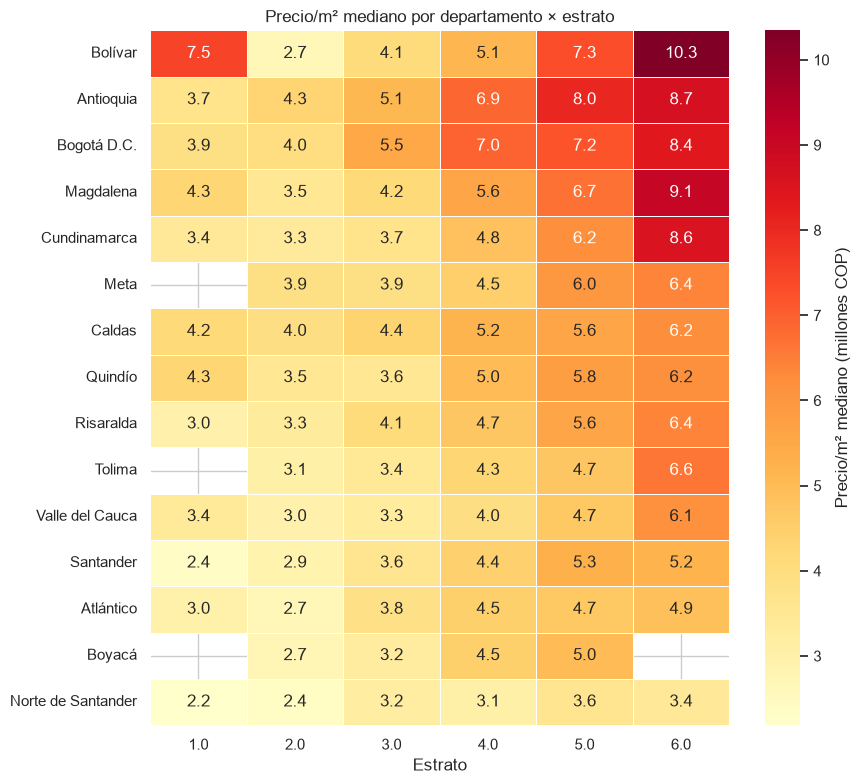

In [12]:
pivot = (
    df[df["department_final"].isin(top_departments) & df["stratum"].notna()]
    .pivot_table(index="department_final", columns="stratum", values="price_per_m2", aggfunc="median")
)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(pivot / 1e6, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "Precio/m² mediano (millones COP)"}, linewidths=0.5)
ax.set_title("Precio/m² mediano por departamento × estrato")
ax.set_xlabel("Estrato")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 11. Amenidades: frecuencia y relación con el precio

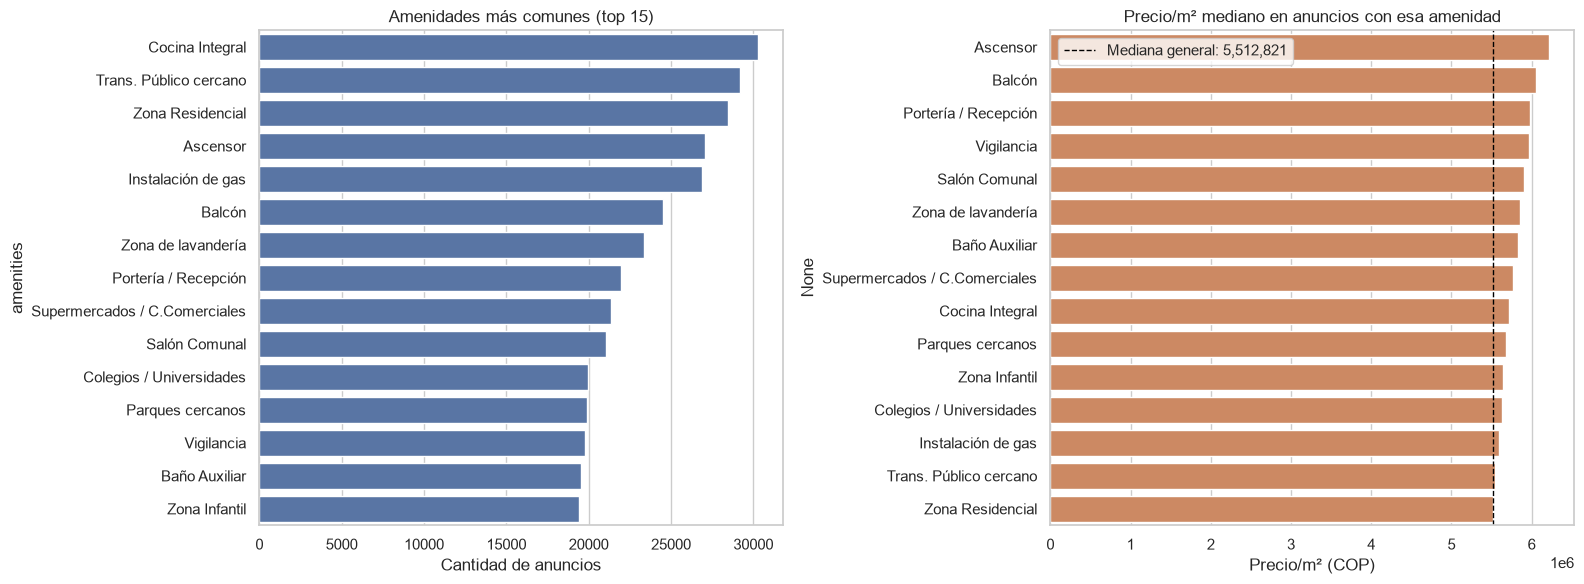

In [13]:
amenities_exploded = df["amenities"].dropna().str.split("; ").explode().str.strip()
top_amenities = amenities_exploded.value_counts().head(15)

price_by_amenity = pd.Series({
    amenity: df.loc[df["amenities"].fillna("").str.contains(amenity, regex=False), "price_per_m2"].median()
    for amenity in top_amenities.index
}).sort_values(ascending=False)

overall_median = df["price_per_m2"].median()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=top_amenities.values, y=top_amenities.index, ax=axes[0], color="#4C72B0")
axes[0].set_title("Amenidades más comunes (top 15)")
axes[0].set_xlabel("Cantidad de anuncios")

sns.barplot(x=price_by_amenity.values, y=price_by_amenity.index, ax=axes[1], color="#DD8452")
axes[1].axvline(overall_median, color="black", linestyle="--", linewidth=1,
                label=f"Mediana general: {overall_median:,.0f}")
axes[1].set_title("Precio/m² mediano en anuncios con esa amenidad")
axes[1].set_xlabel("Precio/m² (COP)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Notas para la fase de modelado

_(completar tras revisar los resultados de arriba con datos reales)_

- Variables con relación clara al precio: `area_m2`, `stratum`, `bedrooms`, `bathrooms`.
- `department_final` / `city` aportan mucha varianza — candidatas a encoding categórico (target encoding o one-hot para las top-N ciudades + "otra").
- Revisar si conviene modelar `log(price_cop)` en vez de `price_cop` directo, dado el sesgo de la distribución.
- Definir estrategia para outliers de precio/m² extremos (¿capping? ¿modelo robusto?).